## 04_4_Clustering_Hierarchical — 셀별 코드
K-Means에서 Group A(전류 7개)가 최적임을 확인했으므로, Hierarchical Clustering도 Group A 고정으로 알고리즘 특성에 집중합니다.

### Cell 1: 라이브러리

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


### Cell 2: 데이터 로드 + 전처리

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")
df_clean = df.dropna().copy()

df_clean['ProtectiveStop_bool'] = df_clean['Robot_ProtectiveStop'].apply(
    lambda x: True if str(x).strip().lower() == 'true' else False
)

# Group A (전류 7개) — K-Means에서 최적으로 선정된 피처 그룹
current_cols = ['Current_J0', 'Current_J1', 'Current_J2',
                'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']

scaler = StandardScaler()
X = scaler.fit_transform(df_clean[current_cols].values)

print(f"데이터: {X.shape[0]}행 × {X.shape[1]}열 (Group A: 전류 7개)")

데이터: 7355행 × 7열 (Group A: 전류 7개)


#### 1. 덴드로그램 (Dendrogram) — Hierarchical Clustering의 고유 시각화
Hierarchical Clustering은 K-Means나 DBSCAN과 달리 데이터가 **어떤 순서로 병합(또는 분할)되는지**를 트리 구조로 보여줄 수 있다.
이를 통해 군집의 자연스러운 계층 구조를 파악하고, 적절한 군집 수를 시각적으로 결정할 수 있다.
Linkage 방법에 따라 군집 병합 기준이 달라지므로, Ward / Complete / Average 세 가지를 비교한다.
- **Ward**: 병합 시 분산 증가량을 최소화 (K-Means와 가장 유사한 철학)
- **Complete**: 두 군집 간 가장 먼 점 사이의 거리를 기준
- **Average**: 두 군집 간 모든 점 쌍의 평균 거리를 기준

### Cell 4: 덴드로그램 — 3가지 Linkage 비교

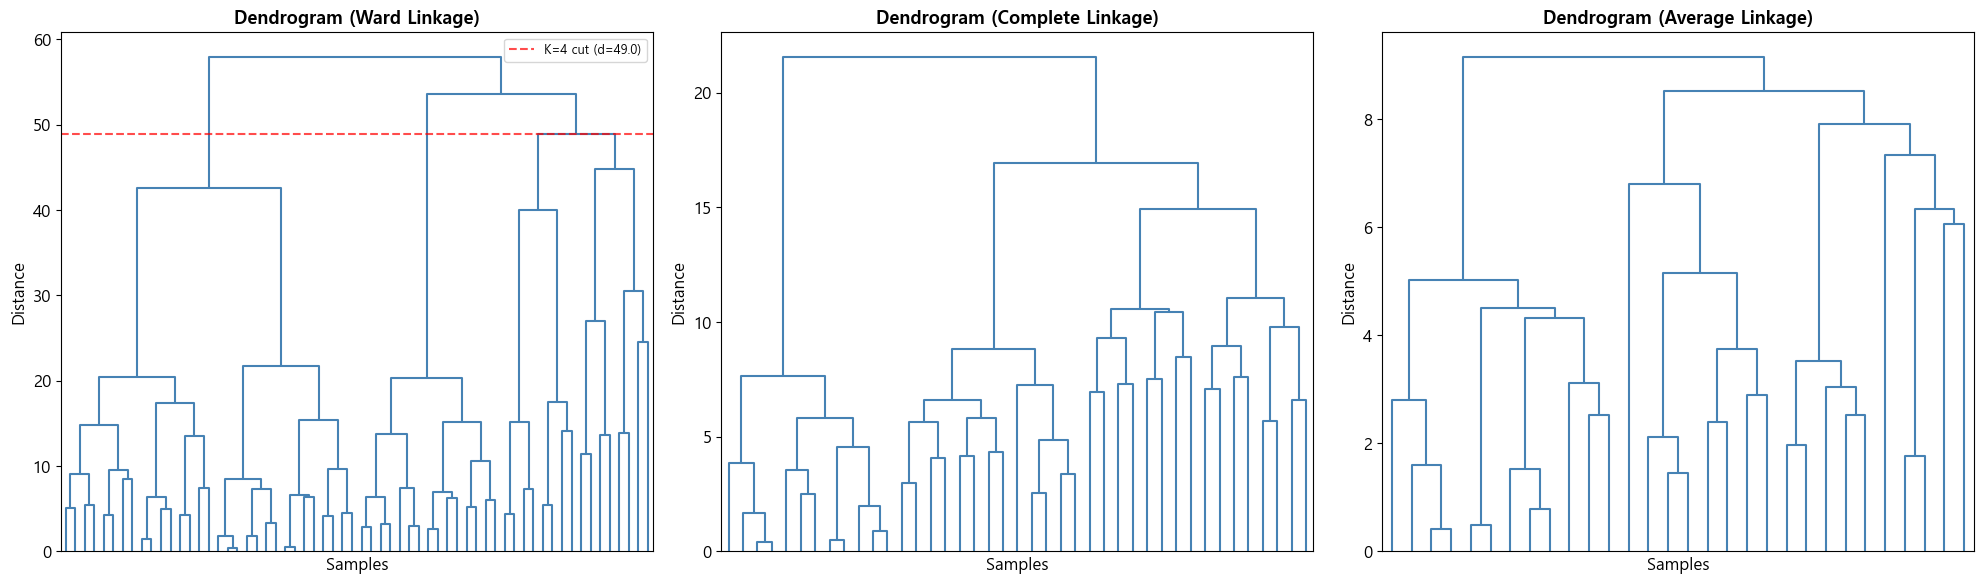

In [4]:
# 데이터가 7,355개로 많으므로 덴드로그램 시각화를 위해 샘플링
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
X_sample = X[sample_idx]

linkage_methods = ['ward', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, method in enumerate(linkage_methods):
    Z = linkage(X_sample, method=method)
    ax = axes[idx]
    dendrogram(Z, ax=ax, truncate_mode='level', p=5,
               no_labels=True, color_threshold=0,
               above_threshold_color='steelblue')
    ax.set_title(f'Dendrogram ({method.capitalize()} Linkage)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Distance')
    
    # K=4 절단선 표시
    if method == 'ward':
        # Ward linkage에서 4개 군집이 되는 높이 추정
        max_d = Z[-3, 2]  # 4번째로 큰 병합 거리 (n-k번째)
        ax.axhline(y=max_d, color='red', linestyle='--', alpha=0.7,
                   label=f'K=4 cut (d={max_d:.1f})')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### 2. Linkage 방법별 성능 비교
동일한 군집 수(K=2~10)에 대해 Ward, Complete, Average linkage의 실루엣 점수를 비교하여 최적의 linkage 방법을 선정한다.

### Cell 6: Linkage × K 그리드 탐색

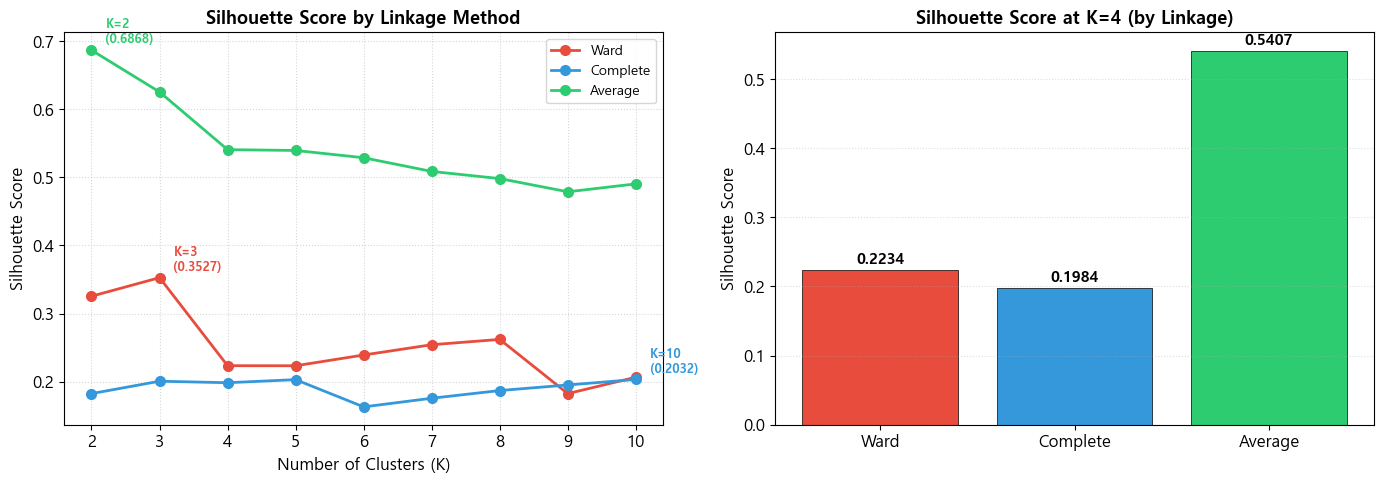

[Linkage × K 그리드 탐색 결과]
linkage  average  complete    ward
K                                 
2         0.6868    0.1824  0.3254
3         0.6254    0.2006  0.3527
4         0.5407    0.1984  0.2234
5         0.5395    0.2029  0.2233
6         0.5288    0.1629  0.2391
7         0.5087    0.1756  0.2542
8         0.4982    0.1869  0.2620
9         0.4788    0.1951  0.1824
10        0.4904    0.2032  0.2065

🏆 최적 조합: Average Linkage, K=2, Silhouette=0.6868


In [5]:
linkage_methods = ['ward', 'complete', 'average']
k_range = range(2, 11)

results = []
for method in linkage_methods:
    for k in k_range:
        model = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)
        
        # 군집 크기 분포
        sizes = [np.sum(labels == c) for c in range(k)]
        max_pct = max(sizes) / len(labels) * 100
        min_size = min(sizes)
        
        results.append({
            'linkage': method, 'K': k,
            'silhouette': round(sil, 4),
            'max_cluster_pct': round(max_pct, 1),
            'min_cluster_size': min_size
        })

df_results = pd.DataFrame(results)

# 실루엣 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: Linkage별 실루엣 추이
ax = axes[0]
colors = {'ward': '#e74c3c', 'complete': '#3498db', 'average': '#2ecc71'}
for method in linkage_methods:
    subset = df_results[df_results['linkage'] == method]
    ax.plot(subset['K'], subset['silhouette'], 'o-', linewidth=2,
            color=colors[method], label=f'{method.capitalize()}', markersize=7)
    
    best_row = subset.loc[subset['silhouette'].idxmax()]
    ax.annotate(f"K={int(best_row['K'])}\n({best_row['silhouette']:.4f})",
                xy=(best_row['K'], best_row['silhouette']),
                fontsize=9, fontweight='bold', color=colors[method],
                textcoords="offset points", xytext=(10, 5))

ax.set_title('Silhouette Score by Linkage Method', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.legend(fontsize=10)
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xticks(range(2, 11))

# 우: K=4 고정 시 Linkage별 비교
ax = axes[1]
k4_data = df_results[df_results['K'] == 4]
bars = ax.bar(k4_data['linkage'].str.capitalize(), k4_data['silhouette'],
              color=[colors[m] for m in k4_data['linkage']],
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, k4_data['silhouette']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Silhouette Score at K=4 (by Linkage)', fontsize=13, fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# 결과 표
print("=" * 70)
print("[Linkage × K 그리드 탐색 결과]")
print("=" * 70)
pivot = df_results.pivot_table(values='silhouette', index='K', columns='linkage')
print(pivot.round(4).to_string())

# 최적 조합
best = df_results.loc[df_results['silhouette'].idxmax()]
print(f"\n🏆 최적 조합: {best['linkage'].capitalize()} Linkage, K={int(best['K'])}, Silhouette={best['silhouette']}")

#### 3. 최적 모델 결과 분석
Linkage 비교에서 선정된 최적 조합으로 Hierarchical Clustering을 수행하고,
K-Means·DBSCAN과 동일한 방식으로 PCA 시각화 및 프로파일링을 진행한다.

### Cell 8: 최적 모델 학습 + PCA 시각화

[Hierarchical] Ward Linkage, K=4
  Silhouette Score: 0.2234
  Cluster 0: 2,307개 (31.4%)
  Cluster 1: 3,850개 (52.3%)
  Cluster 2: 254개 (3.5%)
  Cluster 3: 944개 (12.8%)


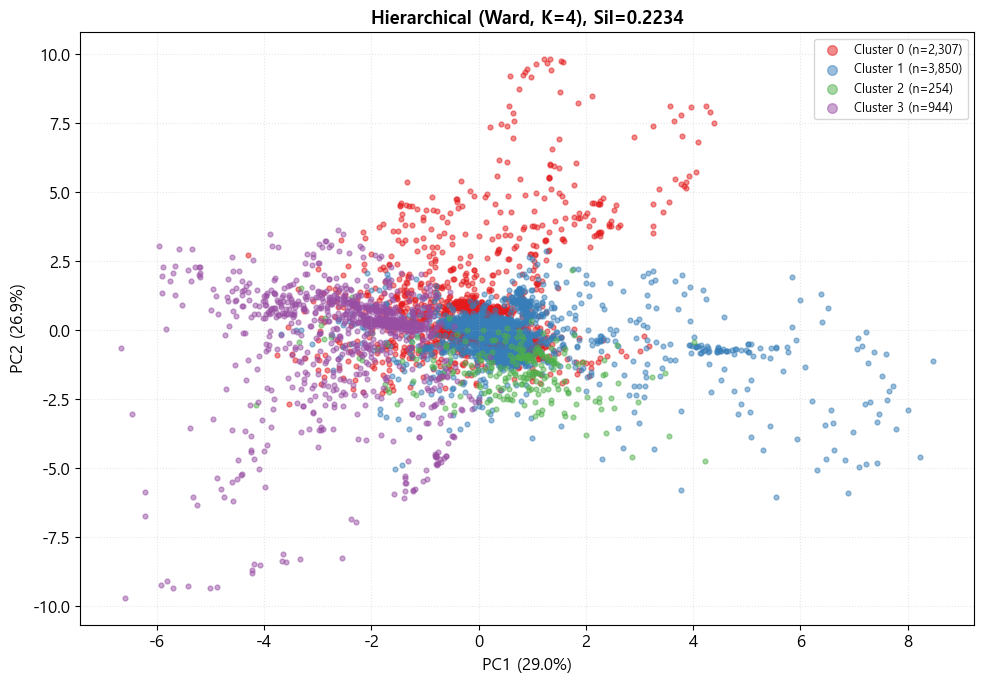

In [14]:
# ⚠️ 위 결과를 보고 최적 linkage와 K를 설정하세요
BEST_LINKAGE = 'ward'#best['linkage']  # 예: 'ward'
BEST_K = 4#int(best['K'])         # 예: 4

model_hc = AgglomerativeClustering(n_clusters=BEST_K, linkage=BEST_LINKAGE)
labels_hc = model_hc.fit_predict(X)
sil_hc = silhouette_score(X, labels_hc)

print(f"[Hierarchical] {BEST_LINKAGE.capitalize()} Linkage, K={BEST_K}")
print(f"  Silhouette Score: {sil_hc:.4f}")
for c_id in range(BEST_K):
    n = (labels_hc == c_id).sum()
    print(f"  Cluster {c_id}: {n:,}개 ({n/len(labels_hc)*100:.1f}%)")

# PCA 시각화
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
cmap = plt.cm.Set1

fig, ax = plt.subplots(figsize=(10, 7))
for c_id in range(BEST_K):
    mask = labels_hc == c_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[cmap(c_id)], alpha=0.5, s=12,
               label=f'Cluster {c_id} (n={mask.sum():,})')

ax.set_title(f'Hierarchical ({BEST_LINKAGE.capitalize()}, K={BEST_K}), Sil={sil_hc:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, loc='best')
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 9: 군집 프로파일링

[Hierarchical] Ward, K=4 — 군집별 피처 평균
            Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current
HC_Cluster                                                                                      
0              -0.3440     -2.2364     -1.3395     -0.5970      0.1867     -0.1163        0.1177
1              -0.0414     -2.0677     -0.9488     -0.4417     -0.0698      0.0623        0.0870
2               0.1808     -2.1075     -1.0880     -0.6987     -0.3644     -0.0154        0.4690
3               0.5710     -3.4387     -1.9089     -1.2679     -0.2526      0.0412        0.0848

[군집 크기]
  Cluster 0: 2,307개 (31.4%)
  Cluster 1: 3,850개 (52.3%)
  Cluster 2: 254개 (3.5%)
  Cluster 3: 944개 (12.8%)


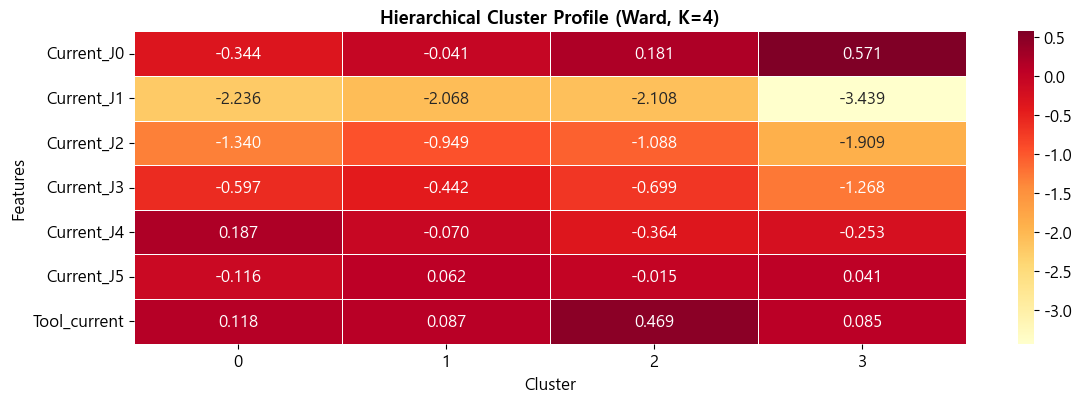

In [15]:
df_clean['HC_Cluster'] = labels_hc

profile_hc = df_clean.groupby('HC_Cluster')[current_cols].mean()

print(f"{'='*70}")
print(f"[Hierarchical] {BEST_LINKAGE.capitalize()}, K={BEST_K} — 군집별 피처 평균")
print(f"{'='*70}")
print(profile_hc.round(4).to_string())

# 군집별 크기
print(f"\n[군집 크기]")
for c_id in range(BEST_K):
    n = (labels_hc == c_id).sum()
    pct = n / len(labels_hc) * 100
    print(f"  Cluster {c_id}: {n:,}개 ({pct:.1f}%)")

# 히트맵
fig, ax = plt.subplots(figsize=(12, max(4, BEST_K * 0.8 + 1)))
sns.heatmap(profile_hc.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title(f'Hierarchical Cluster Profile ({BEST_LINKAGE.capitalize()}, K={BEST_K})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

### Cell 10: Silhouette 샘플 분석

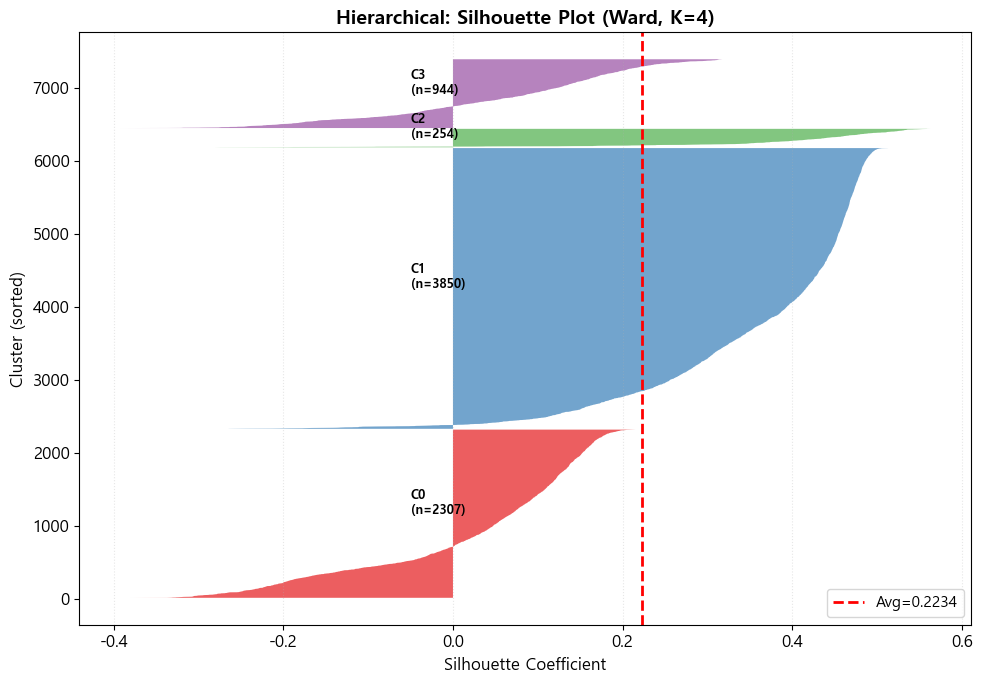

[군집별 Silhouette 통계]
  Cluster 0: mean=0.0301, min=-0.3813, 음수비율=30.4%
  Cluster 1: mean=0.3672, min=-0.2651, 음수비율=1.4%
  Cluster 2: mean=0.3970, min=-0.2813, 음수비율=3.9%
  Cluster 3: mean=0.0624, min=-0.3928, 음수비율=31.6%


In [16]:
sil_samples = silhouette_samples(X, labels_hc)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for c_id in range(BEST_K):
    cluster_sil = np.sort(sil_samples[labels_hc == c_id])
    size = len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, cluster_sil,
                     facecolor=cmap(c_id), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'C{c_id}\n(n={size})',
            fontsize=9, fontweight='bold')
    y_lower += size + 10

ax.axvline(x=sil_hc, color='red', linestyle='--', linewidth=2,
           label=f'Avg={sil_hc:.4f}')
ax.set_title(f'Hierarchical: Silhouette Plot ({BEST_LINKAGE.capitalize()}, K={BEST_K})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster (sorted)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, linestyle=':', alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("[군집별 Silhouette 통계]")
for c_id in range(BEST_K):
    s = sil_samples[labels_hc == c_id]
    neg_pct = (s < 0).sum() / len(s) * 100
    print(f"  Cluster {c_id}: mean={s.mean():.4f}, min={s.min():.4f}, 음수비율={neg_pct:.1f}%")

#### 4. K-Means vs DBSCAN vs Hierarchical — 3모델 종합 비교
동일한 Group A 피처에 대해 세 알고리즘의 결과를 나란히 비교한다.

   K-Means vs DBSCAN vs Hierarchical — 종합 비교 (Group A)
    Metric  K-Means          DBSCAN Hierarchical
      군집 수        4               4            4
       노이즈       없음             79개           없음
Silhouette   0.3814 0.5338 (노이즈 제외)       0.2234
  최대 군집 비율    77.4%           98.3%        52.3%
   핵심 파라미터      K=4  eps=2.0, ms=10    Ward, K=4
   알고리즘 특성 거리 기반 분할        밀도 기반 탐지       계층적 병합


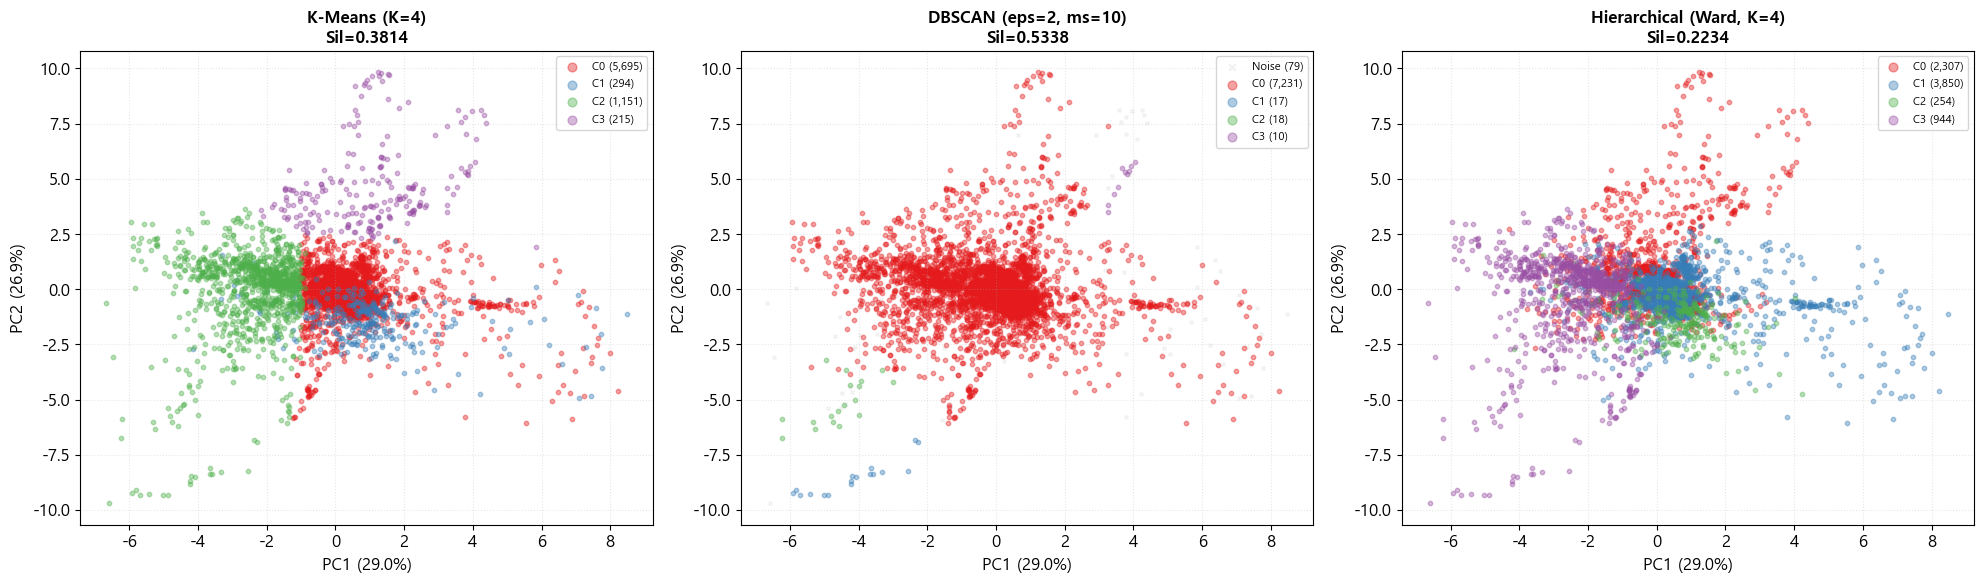

In [17]:
from sklearn.cluster import KMeans, DBSCAN

# K-Means 재학습
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_km = km.fit_predict(X)
sil_km = silhouette_score(X, labels_km)

# DBSCAN 재학습
db = DBSCAN(eps=2.0, min_samples=10)
labels_db = db.fit_predict(X)
mask_db = labels_db != -1
sil_db = silhouette_score(X[mask_db], labels_db[mask_db])
n_noise_db = (labels_db == -1).sum()
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

# 종합 비교표
print("=" * 75)
print("   K-Means vs DBSCAN vs Hierarchical — 종합 비교 (Group A)")
print("=" * 75)

comparison = pd.DataFrame({
    'Metric': ['군집 수', '노이즈', 'Silhouette', '최대 군집 비율',
               '핵심 파라미터', '알고리즘 특성'],
    'K-Means': ['4', '없음', f'{sil_km:.4f}', 
                f'{max([(labels_km==c).sum() for c in range(4)])/len(labels_km)*100:.1f}%',
                'K=4', '거리 기반 분할'],
    'DBSCAN': [str(n_clusters_db), f'{n_noise_db}개', f'{sil_db:.4f} (노이즈 제외)',
               f'{max([(labels_db==c).sum() for c in set(labels_db) if c!=-1])/len(labels_db)*100:.1f}%',
               'eps=2.0, ms=10', '밀도 기반 탐지'],
    'Hierarchical': [str(BEST_K), '없음', f'{sil_hc:.4f}',
                     f'{max([(labels_hc==c).sum() for c in range(BEST_K)])/len(labels_hc)*100:.1f}%',
                     f'{BEST_LINKAGE.capitalize()}, K={BEST_K}', '계층적 병합']
})
print(comparison.to_string(index=False))

# PCA 3모델 나란히
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
ax = axes[0]
for c_id in range(4):
    m = labels_km == c_id
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=[cmap(c_id)], alpha=0.4, s=10,
               label=f'C{c_id} ({m.sum():,})')
ax.set_title(f'K-Means (K=4)\nSil={sil_km:.4f}', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

# DBSCAN
ax = axes[1]
noise_m = labels_db == -1
if noise_m.sum() > 0:
    ax.scatter(X_pca[noise_m, 0], X_pca[noise_m, 1],
               c='lightgray', alpha=0.3, s=6, marker='x',
               label=f'Noise ({noise_m.sum():,})')
for c_id in sorted(set(labels_db)):
    if c_id == -1: continue
    m = labels_db == c_id
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=[cmap(c_id % 10)], alpha=0.4, s=10,
               label=f'C{c_id} ({m.sum():,})')
ax.set_title(f'DBSCAN (eps=2, ms=10)\nSil={sil_db:.4f}', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

# Hierarchical
ax = axes[2]
for c_id in range(BEST_K):
    m = labels_hc == c_id
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=[cmap(c_id)], alpha=0.4, s=10,
               label=f'C{c_id} ({m.sum():,})')
ax.set_title(f'Hierarchical ({BEST_LINKAGE.capitalize()}, K={BEST_K})\nSil={sil_hc:.4f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

### Cell 13: 외부 검증 (에러 라벨)

[외부 검증] Hierarchical (Ward, K=4) — 군집별 에러 발생률
 Cluster  Total  Grip Lost (%)  Protective Stop (%)
       0   2307           4.81                 0.91
       1   3850           3.22                 2.21
       2    254           0.79                 1.18
       3    944           0.64                17.90


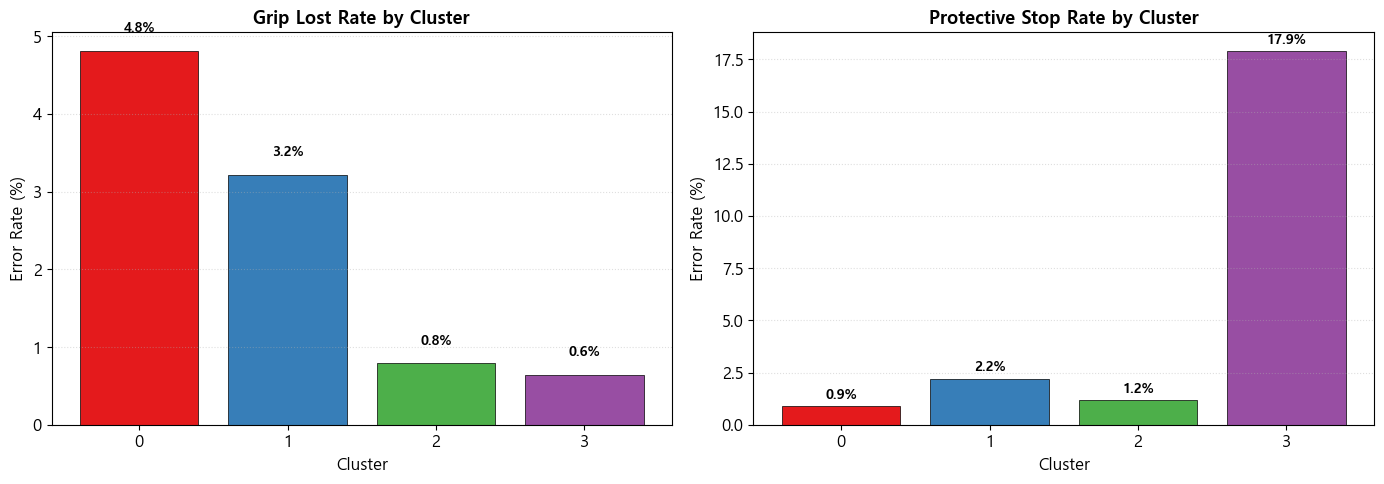

In [18]:
best_col = 'HC_Cluster'

error_rows = []
for c_id in range(BEST_K):
    subset = df_clean[df_clean[best_col] == c_id]
    n = len(subset)
    error_rows.append({
        'Cluster': c_id, 'Total': n,
        'Grip Lost (%)': round(subset['grip_lost'].sum() / n * 100, 2),
        'Protective Stop (%)': round(subset['ProtectiveStop_bool'].sum() / n * 100, 2)
    })

df_error = pd.DataFrame(error_rows)
print("=" * 65)
print(f"[외부 검증] Hierarchical ({BEST_LINKAGE.capitalize()}, K={BEST_K}) — 군집별 에러 발생률")
print("=" * 65)
print(df_error.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col, title) in enumerate([
    ('Grip Lost (%)', 'Grip Lost Rate by Cluster'),
    ('Protective Stop (%)', 'Protective Stop Rate by Cluster')
]):
    ax = axes[idx]
    bars = ax.bar(df_error['Cluster'].astype(str), df_error[col],
                  color=[cmap(i) for i in range(BEST_K)],
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, df_error[col]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Error Rate (%)')
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

### Cell 14: 3모델 교차표 (K-Means ↔ Hierarchical)

In [19]:
# K-Means ↔ Hierarchical
print("=" * 65)
print("[교차표] K-Means vs Hierarchical")
print("=" * 65)
ct_km_hc = pd.crosstab(labels_km, labels_hc,
                        rownames=['KMeans'], colnames=['Hierarchical'],
                        margins=True, margins_name='Total')
print(ct_km_hc)

ari_km_hc = adjusted_rand_score(labels_km, labels_hc)
nmi_km_hc = normalized_mutual_info_score(labels_km, labels_hc)
print(f"\n  ARI = {ari_km_hc:.4f}")
print(f"  NMI = {nmi_km_hc:.4f}")

# DBSCAN ↔ Hierarchical
print(f"\n{'='*65}")
print("[교차표] DBSCAN vs Hierarchical")
print("=" * 65)
ct_db_hc = pd.crosstab(labels_db, labels_hc,
                        rownames=['DBSCAN'], colnames=['Hierarchical'],
                        margins=True, margins_name='Total')
print(ct_db_hc)

ari_db_hc = adjusted_rand_score(labels_db, labels_hc)
nmi_db_hc = normalized_mutual_info_score(labels_db, labels_hc)
print(f"\n  ARI = {ari_db_hc:.4f}")
print(f"  NMI = {nmi_db_hc:.4f}")

[교차표] K-Means vs Hierarchical
Hierarchical     0     1    2    3  Total
KMeans                                   
0             1853  3734    6  102   5695
1               23    23  248    0    294
2              221    88    0  842   1151
3              210     5    0    0    215
Total         2307  3850  254  944   7355

  ARI = 0.3529
  NMI = 0.4246

[교차표] DBSCAN vs Hierarchical
Hierarchical     0     1    2    3  Total
DBSCAN                                   
-1              15    25   23   16     79
0             2282  3825  231  893   7231
1                0     0    0   17     17
2                0     0    0   18     18
3               10     0    0    0     10
Total         2307  3850  254  944   7355

  ARI = 0.0180
  NMI = 0.0278


### Cell 15: 3모델 종합 요약

In [20]:
print("=" * 75)
print("   📊 3모델 종합 요약 (Group A: 전류 7개)")
print("=" * 75)

summary = pd.DataFrame({
    '알고리즘': ['K-Means', 'DBSCAN', 'Hierarchical'],
    '군집 수': [4, n_clusters_db, BEST_K],
    'Silhouette': [f'{sil_km:.4f}', f'{sil_db:.4f}*', f'{sil_hc:.4f}'],
    '노이즈': ['0', str(n_noise_db), '0'],
    '강점': ['거시적 상태 분류', '이상치 탐지', '계층적 구조 파악'],
    '약점': ['이상치 강제 할당', '연속 데이터에서 과소분류', '대용량 데이터 시 비효율']
})
print(summary.to_string(index=False))
print("\n* DBSCAN Silhouette은 노이즈 제외 후 계산")

# K-Means ↔ Hierarchical ARI/NMI
print(f"\n[라벨 일치도]")
print(f"  K-Means ↔ Hierarchical: ARI={ari_km_hc:.4f}, NMI={nmi_km_hc:.4f}")
print(f"  K-Means ↔ DBSCAN:      ARI={adjusted_rand_score(labels_km, labels_db):.4f}, NMI={normalized_mutual_info_score(labels_km, labels_db):.4f}")
print(f"  DBSCAN ↔ Hierarchical:  ARI={ari_db_hc:.4f}, NMI={nmi_db_hc:.4f}")

   📊 3모델 종합 요약 (Group A: 전류 7개)
        알고리즘  군집 수 Silhouette 노이즈        강점            약점
     K-Means     4     0.3814   0 거시적 상태 분류     이상치 강제 할당
      DBSCAN     4    0.5338*  79    이상치 탐지 연속 데이터에서 과소분류
Hierarchical     4     0.2234   0 계층적 구조 파악 대용량 데이터 시 비효율

* DBSCAN Silhouette은 노이즈 제외 후 계산

[라벨 일치도]
  K-Means ↔ Hierarchical: ARI=0.3529, NMI=0.4246
  K-Means ↔ DBSCAN:      ARI=0.0865, NMI=0.0732
  DBSCAN ↔ Hierarchical:  ARI=0.0180, NMI=0.0278
